# 02 - Exploratory Data Analysis

**Goal:** Explore the cleaned dataset to understand which customer attributes are most associated with churn, ahead of feature engineering and modeling.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/telco_churn_clean.csv")

In [2]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,charge_bin
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,"(18.15, 38.35]"
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,"(38.35, 58.45]"
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,"(38.35, 58.45]"
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,"(38.35, 58.45]"
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,"(58.45, 78.55]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,"(78.55, 98.65]"
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,"(98.65, 118.75]"
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,"(18.15, 38.35]"
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1,"(58.45, 78.55]"


In [3]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

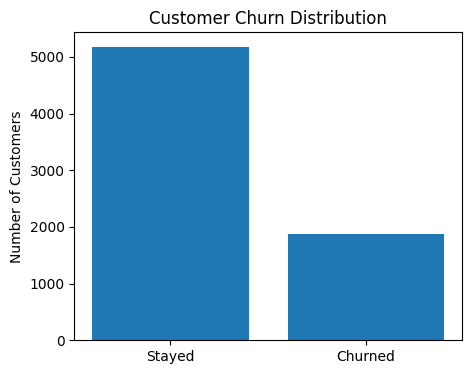

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(["Stayed", "Churned"], churn_counts)

plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")

plt.show()

Approximately 27% of customers have churned, while 73% remain. This indicates a moderately imbalanced classification problem and suggests that customer retention is generally strong, although a significant minority of customers leave the service.

### Does customer tenure affect churn?

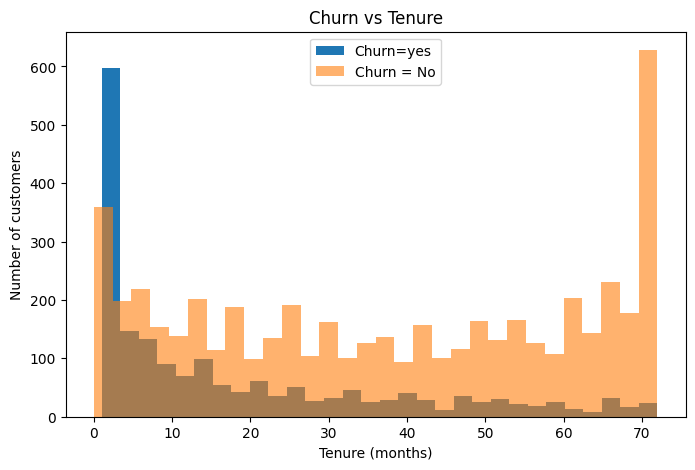

In [7]:
churn_yes = df[df["Churn"]==1]["tenure"]
churn_no = df[df["Churn"] == 0]["tenure"]

plt.figure(figsize=(8,5))
plt.hist(churn_yes, bins=30, alpha=1, label= "Churn=yes")
plt.hist(churn_no, bins=30, alpha=0.6, label="Churn = No")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of customers")
plt.title("Churn vs Tenure")
plt.legend()

plt.show()

### Does monthly charge affect churn?

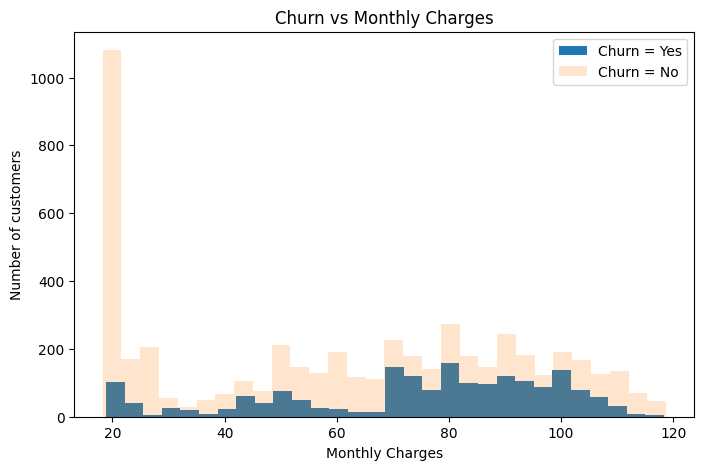

In [8]:
plt.figure(figsize = (8,5))

plt.hist(df[df["Churn"]== 1]["MonthlyCharges"], bins = 30 , alpha=1, label = "Churn = Yes")
plt.hist(df[df["Churn"] == 0]["MonthlyCharges"], bins=30, alpha=0.2, label="Churn = No")

plt.xlabel("Monthly Charges")
plt.ylabel("Number of customers")
plt.title("Churn vs Monthly Charges")
plt.legend()

plt.show()

### Does contract type affect churn?

In [11]:
df["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

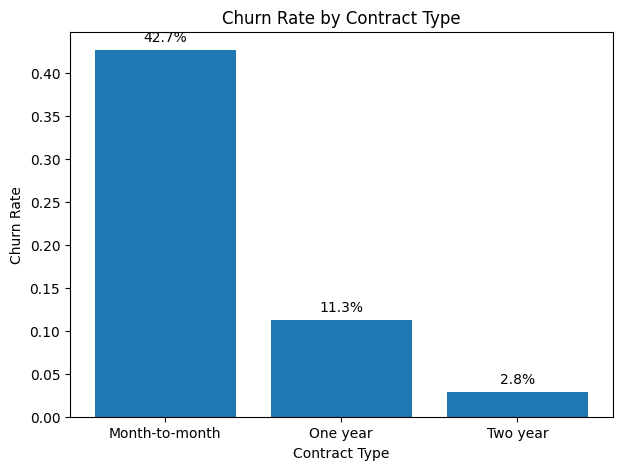

In [13]:
contract_churn= df.groupby("Contract")["Churn"].mean()

plt.figure(figsize=(7,5))

bars = plt.bar(contract_churn.index, contract_churn.values)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.1%}",
        ha="center"
    )

plt.show()

In [20]:
q=df.groupby("Contract")["Churn"].value_counts().unstack()
q

Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


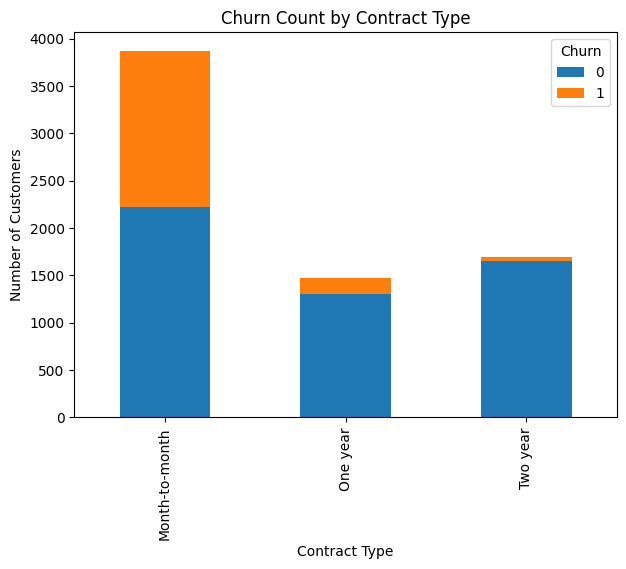

In [22]:
contract_churn_counts = df.groupby("Contract")["Churn"].value_counts().unstack()

contract_churn_counts.plot(kind="bar", stacked=True, figsize=(7,5))

plt.title("Churn Count by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Does internet service type affect churn?

In [23]:
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [24]:
internet_churn = df.groupby("InternetService")["Churn"].mean()
internet_churn

InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64

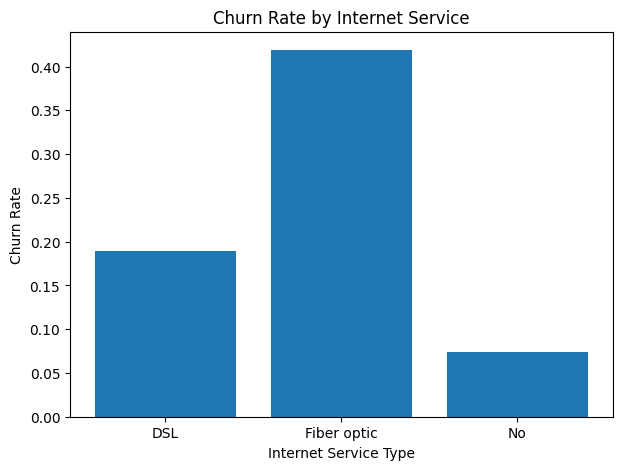

In [25]:
plt.figure(figsize=(7,5))

plt.bar(internet_churn.index, internet_churn.values)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate")

plt.show()

### Insight: Internet service type impacts churn behavior

- Customers with fiber optic internet show higher churn rates.
- DSL users have comparatively lower churn.
- Customers without internet service show the lowest churn, likely due to lower engagement and fewer service dependencies.

### Does payment method affect churn?

In [27]:
df["PaymentMethod"].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [29]:
payment_churn=df.groupby("PaymentMethod")["Churn"].mean()
payment_churn

PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64

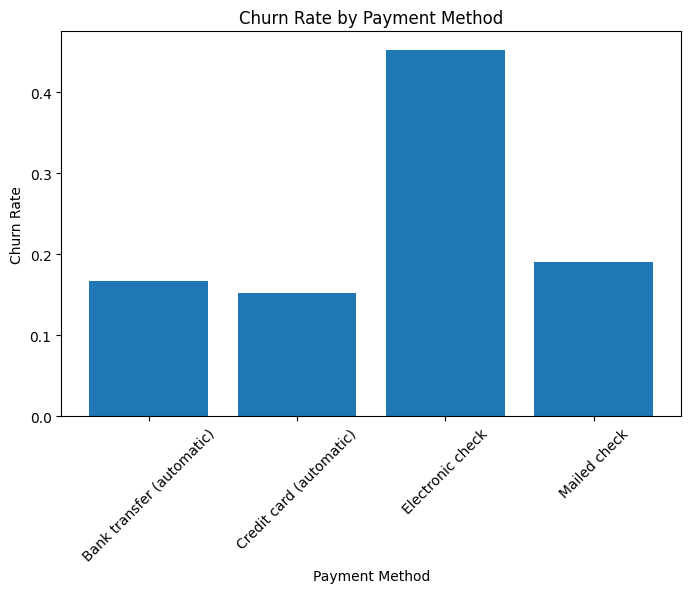

In [30]:
plt.figure(figsize=(8,5))

plt.bar(payment_churn.index, payment_churn.values)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")

plt.xticks(rotation=45)

plt.show()



### Insight: Payment method strongly correlates with churn

- Customers using electronic check show the highest churn rates.
- Automatic payment methods (credit card or bank transfer) are associated with lower churn.
- This suggests that payment automation is linked to higher customer retention.

### Does tech support affect churn?

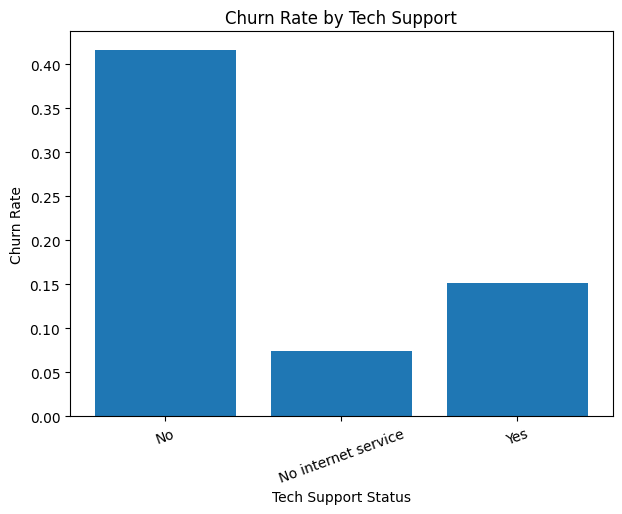

In [32]:
import matplotlib.pyplot as plt

tech_churn = df.groupby("TechSupport")["Churn"].mean()

plt.figure(figsize=(7,5))

plt.bar(tech_churn.index, tech_churn.values)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support Status")
plt.ylabel("Churn Rate")

plt.xticks(rotation=20)

plt.show()

### Insight: Tech support availability strongly reduces churn

- Customers without tech support have significantly higher churn rates.
- Customers with tech support are more likely to stay, indicating improved satisfaction and retention.
- This suggests that service support quality is a key driver of customer retention.

### Correlation between numeric features and churn

In [33]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
0,0,1,29.85,29.85,0
1,0,34,56.95,1889.50,0
2,0,2,53.85,108.15,1
3,0,45,42.30,1840.75,0
4,0,2,70.70,151.65,1


In [34]:
corr = numeric_df.corr()
corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.150889
tenure,0.016567,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.103006,0.826178,0.651174,1.000000,-0.198324
Churn,0.150889,-0.352229,0.193356,-0.198324,1.000000


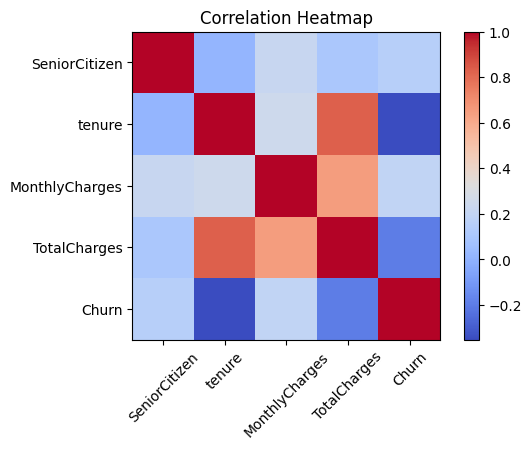

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

In [36]:
corr["Churn"].sort_values(ascending=False)

Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.198324
tenure           -0.352229
Name: Churn, dtype: float64

### Distribution comparison: churned vs retained customers

<Figure size 700x500 with 0 Axes>

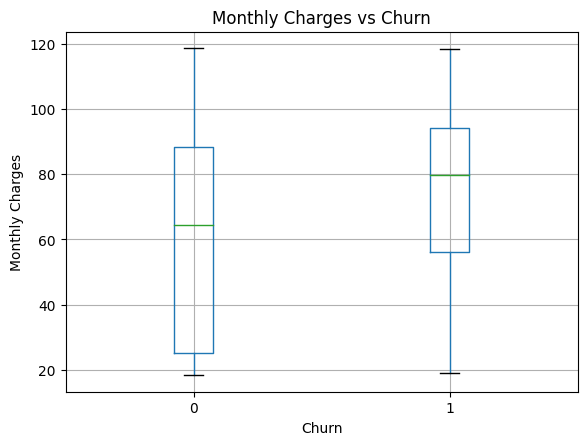

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges vs Churn")
plt.suptitle("")  # removes default pandas title
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

<Figure size 700x500 with 0 Axes>

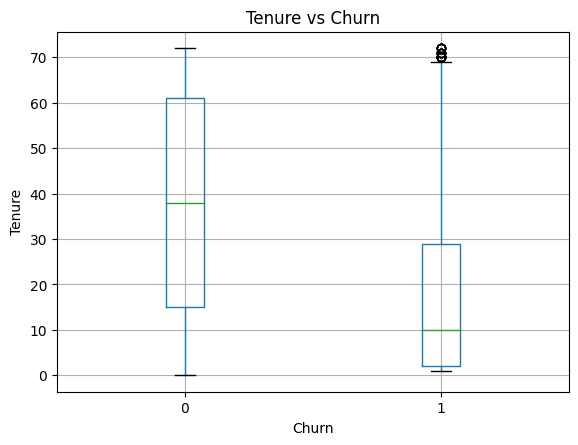

In [38]:
plt.figure(figsize=(7,5))

df.boxplot(column="tenure", by="Churn")

plt.title("Tenure vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

### Summary of EDA findings

- **Tenure** is the strongest churn driver: new customers churn far more than long-tenured ones
- **Contract type** matters a lot: month-to-month customers churn at a much higher rate than 1- or 2-year contract customers
- **Fiber optic internet** customers churn more than DSL or no-internet customers
- **Electronic check** payment is associated with the highest churn rate; automatic payment methods (credit card, bank transfer) correlate with better retention
- **Tech support** availability is strongly protective against churn
- **Monthly charges** are positively correlated with churn, but less strongly than tenure or contract type

**Next:** [`03_feature_engineering.ipynb`](./03_feature_engineering.ipynb) — encode features and prepare train/test splits for modeling.